# End-to-end ML project (regression)

1. [Get the Data](#get-the-data)
2. [Create a Test Set](#create-a-test-set)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
    * [Visualizing Geo Data](#visualizing-geographical-data)
    * [Looking for Correlations](#looking-for-correlations)
    * [Attribute Combination](#attribute-combinations)
4. [Prepare Data for ML Algorithms](#prepare-the-data-for-ml-algorithms)
    * [Get the Labels](#get-the-labels)
    * [Data Cleaning](#data-cleaning)
    * [Text and Categorical Attributes](#handling-text-and-categorical-attributes)
    * [Feature Scaling](#feature-scaling)
    * [Transformation Pipelines](#transformation-pipelines)
5. [Select and Train a Model](#select-and-train-a-model)
    * [Train Set Evaluation](#training-and-evaluating-on-the-training-set)
    * [Cross Validation](#using-cross-validation)
    * [Fine-Tuning](#model-fine-tuning)
    * [Test Set Evaluation](#evaluate-our-model-on-the-test-set)
    

Import libraries

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from scipy import stats # for p values
from sklearn.preprocessing import PowerTransformer # yeo-johnson transformation, which can handle zero and negative values, unlike log transformation and guessing

## Get the Data

In [8]:
bank_x_train = pd.read_csv("bank_x_train.csv")
bank_y_train = pd.read_csv("bank_y_train.csv")
bank_x_test = pd.read_csv("bank_x_test.csv")
bank_total_no_labels = pd.concat([bank_x_train, bank_x_test], ignore_index=True)
bank_labeled = pd.concat([bank_x_train, bank_y_train], axis=1)

## Info on Data

In [9]:
bank_total_no_labels.head()
bank_labeled.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,33,blue-collar,single,secondary,no,328,yes,no,unknown,9,may,142,2.0,-1,0,unknown,1
1,50,management,divorced,secondary,no,458,no,no,cellular,3,feb,184,3.0,-1,0,unknown,1
2,38,management,married,tertiary,no,536,yes,no,cellular,22,oct,234,1.0,92,1,success,2
3,27,self-employed,single,secondary,no,78,yes,no,unknown,9,may,825,1.0,-1,0,unknown,1
4,31,housemaid,married,primary,no,2603,yes,no,cellular,18,nov,224,1.0,-1,0,unknown,1


In [10]:
bank_total_no_labels.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,43857.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.766902,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.102837,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


| Feature   | Type        | Meaning                                                                              |
| --------- | ----------- | ------------------------------------------------------------------------------------ |
| age       | Numeric     | Client's age in years                                                                |
| job       | Categorical | Type of job (e.g., admin, blue-collar, management, student)                          |
| marital   | Categorical | Marital status: married, single, divorced (incl. widowed)                            |
| education | Categorical | Education level: primary, secondary, tertiary, unknown                               |
| default   | Binary      | Has credit in default? (yes/no)                                                      |
| balance   | Numeric     | Average yearly bank balance in euros                                                 |
| housing   | Binary      | Has a housing loan? (yes/no)                                                         |
| loan      | Binary      | Has a personal loan? (yes/no)                                                        |
| contact   | Categorical | Contact type: cellular, telephone, unknown                                           |
| day       | Numeric     | Last contact day of the month                                                        |
| month     | Categorical | Last contact month (jan–dec)                                                         |
| duration  | Numeric     | Last contact duration in seconds                                                     |
| campaign  | Numeric     | Number of contacts made during this campaign (incl. last)                            |
| pdays     | Numeric     | Days since client was last contacted from a previous campaign (−1 = never contacted) |
| previous  | Numeric     | Number of contacts made before this campaign                                         |
| poutcome  | Categorical | Outcome of the previous campaign: success, failure, other, unknown                   |

In [11]:
bank_total_no_labels[bank_total_no_labels.isnull().any(axis=1)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
5,39,technician,single,NaN,no,4646,yes,no,cellular,18,nov,486,1.0,-1,0,unknown
8,29,technician,single,NaN,no,-247,no,yes,cellular,22,jul,211,1.0,-1,0,unknown
17,29,NaN,single,tertiary,no,640,no,no,cellular,8,jul,150,2.0,-1,0,unknown
19,44,NaN,married,primary,no,-92,no,yes,cellular,28,jul,526,5.0,-1,0,unknown
22,33,management,married,tertiary,no,685,NaN,no,unknown,17,nov,53,1.0,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45194,43,management,married,NaN,no,0,no,no,telephone,17,oct,147,1.0,-1,0,unknown
45195,36,management,married,tertiary,no,2609,NaN,no,unknown,30,may,141,9.0,-1,0,unknown
45199,27,admin.,single,NaN,no,585,no,no,unknown,3,jul,269,3.0,-1,0,unknown
45200,33,admin.,single,NaN,no,690,no,no,cellular,10,nov,223,3.0,555,16,failure


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

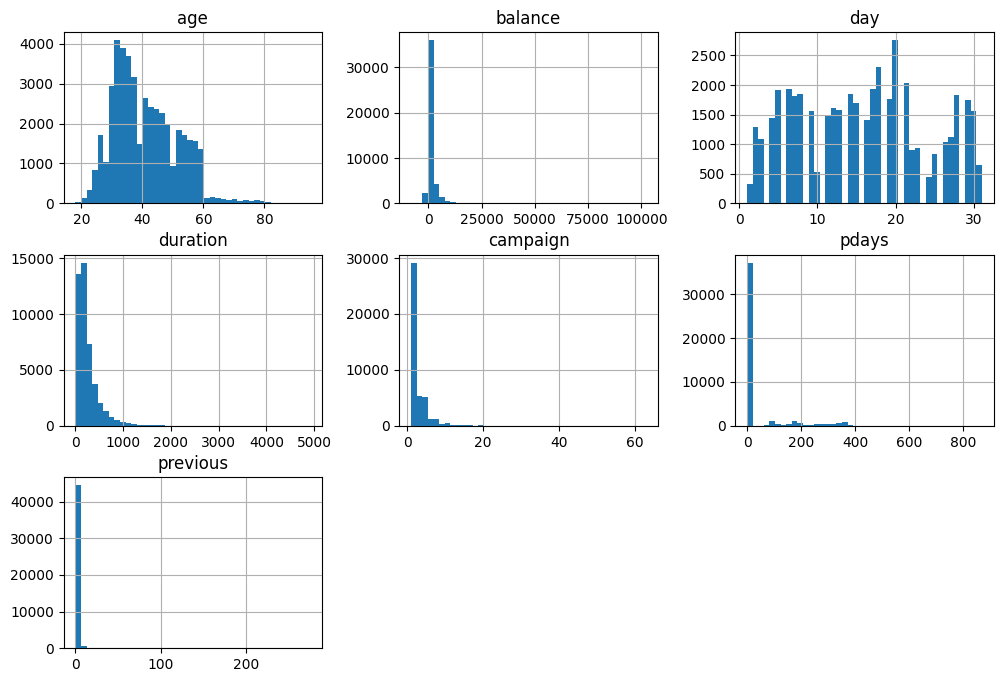

In [12]:
bank_total_no_labels.hist(bins=42, figsize=(12, 8))

## Exploratory Data Analysis

For the sake of discussion, we assume both datasets "bank_labeled" and "bank_total_no_labels" to be closely resebling each other i.e. analyzing one will yield strong resutls about the other.

In [13]:
bank_total_no_labels["month"] = pd.to_datetime(bank_total_no_labels['month'], format='%b').dt.month
bank_labeled["month"] = pd.to_datetime(bank_labeled['month'], format='%b').dt.month
bank_x_train["month"] = pd.to_datetime(bank_x_train['month'], format='%b').dt.month
bank_x_test["month"] = pd.to_datetime(bank_x_test['month'], format='%b').dt.month

bank_total_no_labels.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,33,blue-collar,single,secondary,no,328,yes,no,unknown,9,5,142,2.0,-1,0,unknown
1,50,management,divorced,secondary,no,458,no,no,cellular,3,2,184,3.0,-1,0,unknown
2,38,management,married,tertiary,no,536,yes,no,cellular,22,10,234,1.0,92,1,success
3,27,self-employed,single,secondary,no,78,yes,no,unknown,9,5,825,1.0,-1,0,unknown
4,31,housemaid,married,primary,no,2603,yes,no,cellular,18,11,224,1.0,-1,0,unknown


### Looking for Correlations

Remember that this measures only **linear correlations**!

In [14]:
# notice the numeric_only parameter!
corr_matrix = bank_labeled.corr(numeric_only=True)

In [15]:
corr_matrix["duration"].sort_values(ascending=False)

duration    1.000000
y           0.390298
balance     0.026708
previous    0.000255
pdays       0.000220
age        -0.000423
month      -0.009962
day        -0.031295
campaign   -0.083284
Name: duration, dtype: float64

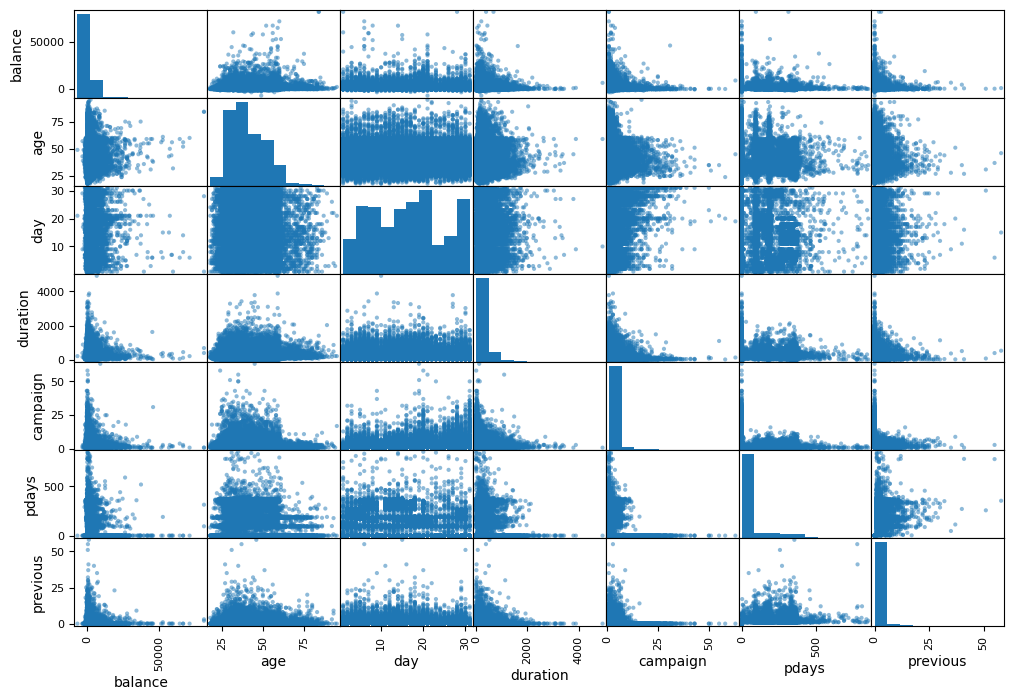

In [16]:
from pandas.plotting import scatter_matrix

attributes = ["balance", "age", "day", "duration", "campaign", "pdays", "previous"]
scatter_matrix(bank_labeled[attributes], figsize=(12, 8))
plt.show()

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Use only the numeric attributes for clustering
corr = bank_labeled[attributes].corr(numeric_only=True)
linkage = hierarchy.linkage(squareform(1 - corr.abs()), method='average')

plt.figure(figsize=(10, 6))
dendro = hierarchy.dendrogram(linkage, labels=attributes + ["y"], leaf_rotation=90)

plt.axhline(0.2, color='r', linestyle='--')  # arbitrary thresholds
plt.axhline(0.5, color='g', linestyle='--')
plt.show()

The columns balance, duration, campaign, pdays, and previous are all heavily right skewed, so there may or may not exist certain non linear correlation, which we are going to check for.
Or, in other words, everything except for age and day.

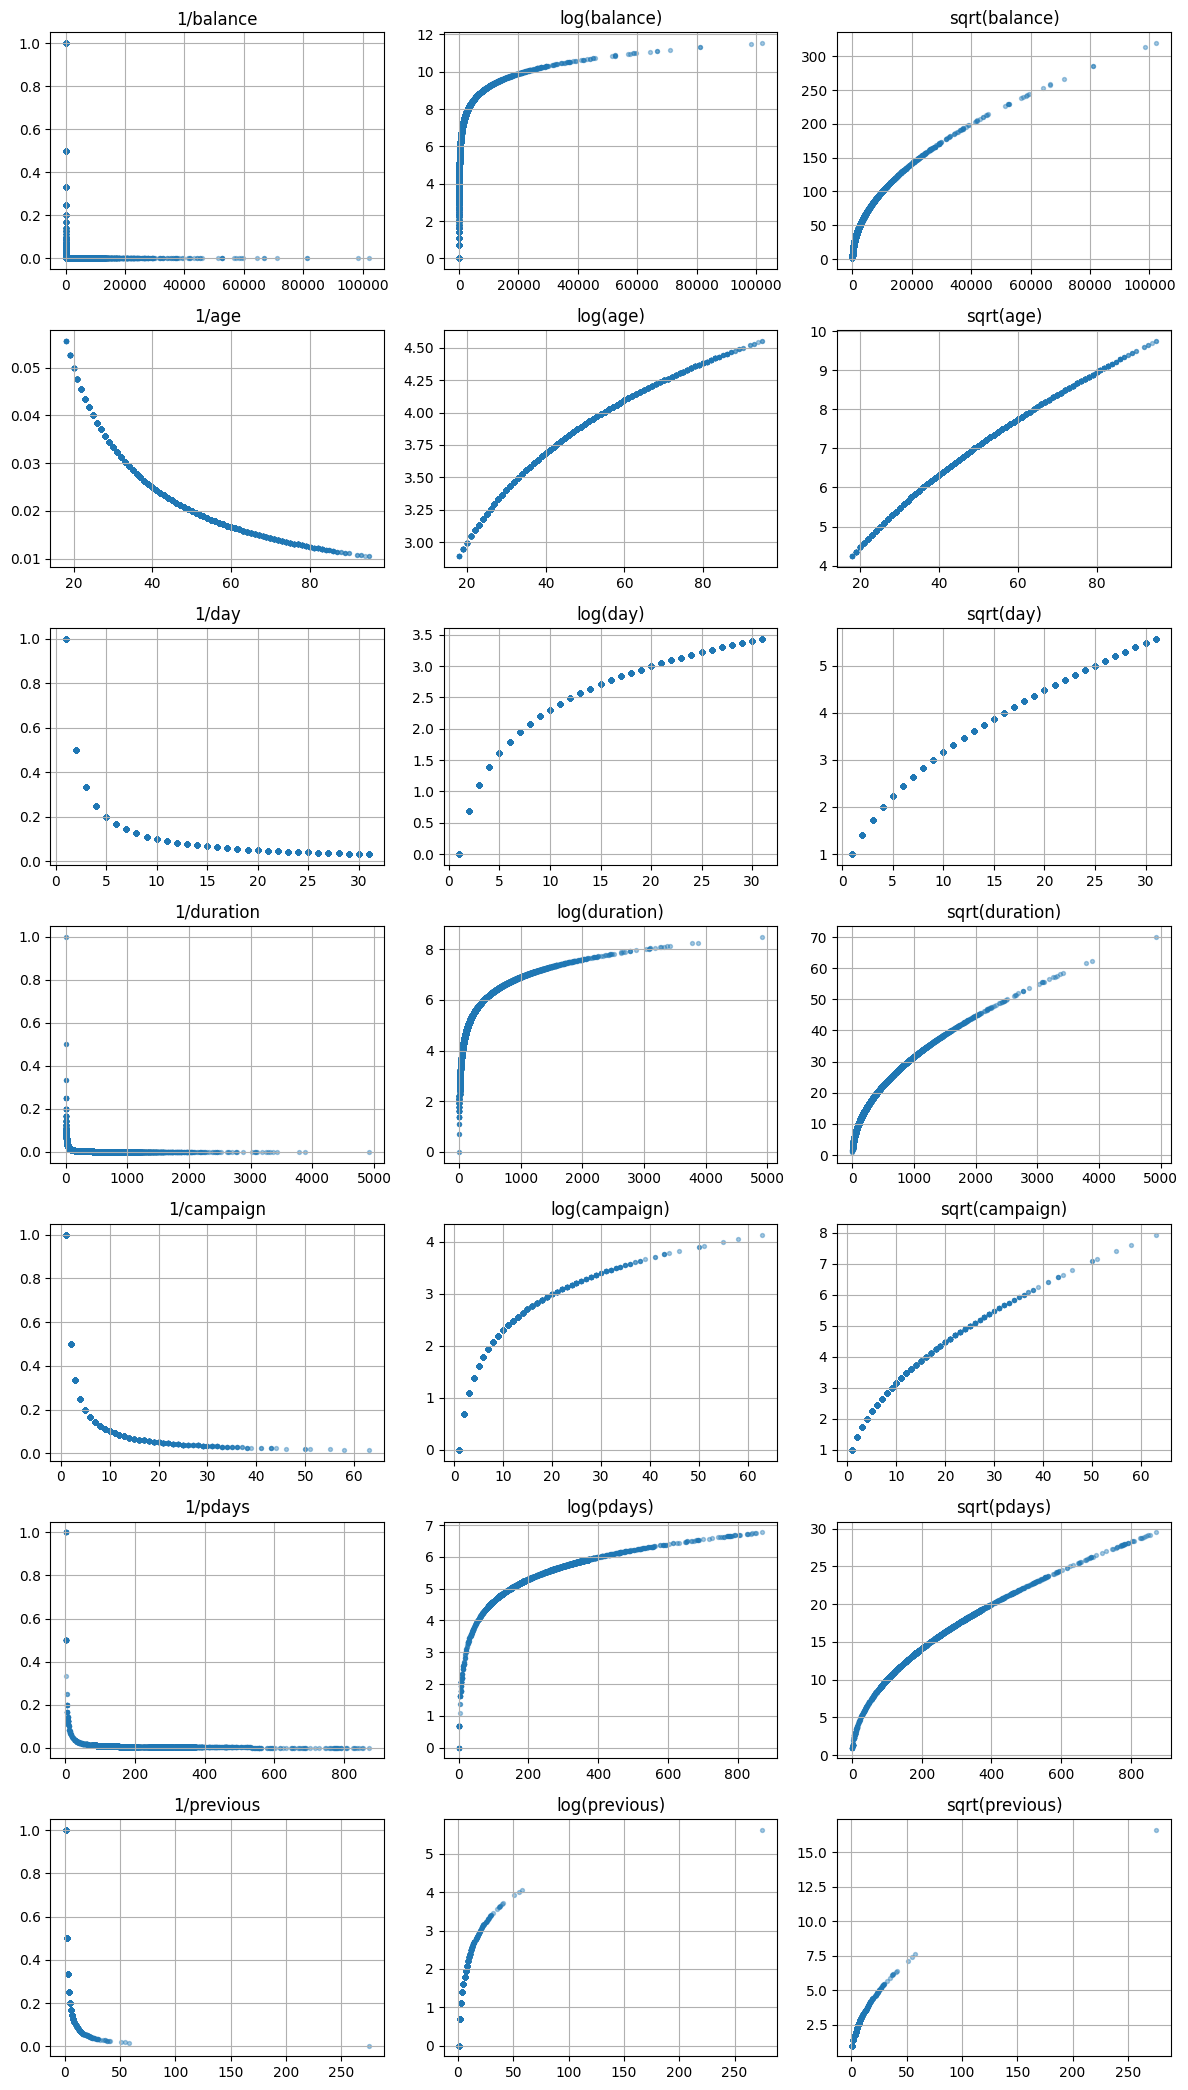

In [17]:
fig, axes = plt.subplots(7, 3, figsize=(12, 7*3)) 

for i, col in enumerate(non_linear_assumptions): # first time using enumerate, wow

    x = bank_total_no_labels[col].astype(float)
    x_pos = x[x > 0] # Filter out non-positive values for log and sqrt transformations


    axes[i, 0].scatter(x_pos, 1 / x_pos, s=8, alpha=0.4)
    axes[i, 0].grid(True) # Add grid to the first subplot this way, as it doesn't work with scatter() directly for some reason
    axes[i, 0].set_title(f"1/{col}")

    axes[i, 1].scatter(x_pos, np.log(x_pos), s=8, alpha=0.4)
    axes[i, 1].grid(True)
    axes[i, 1].set_title(f"log({col})")

    axes[i, 2].scatter(x_pos, np.sqrt(x_pos), s=8, alpha=0.4)
    axes[i, 2].grid(True)
    axes[i, 2].set_title(f"sqrt({col})")

plt.tight_layout()

In [18]:
# next snipet shows the same subplots but with 0,0 point included to see if the chart is centered around it, 
# as well as adding best fit lines to see if the transformation is linearizing the relationship with the target variable,
#  which is what we want to achieve with these transformations.
# eyes can be misled thus i added some methods from my Rstudio days to calculate the p values for the correlation between the transformed features 
# and the best fit line to asses their linearity after transformation.

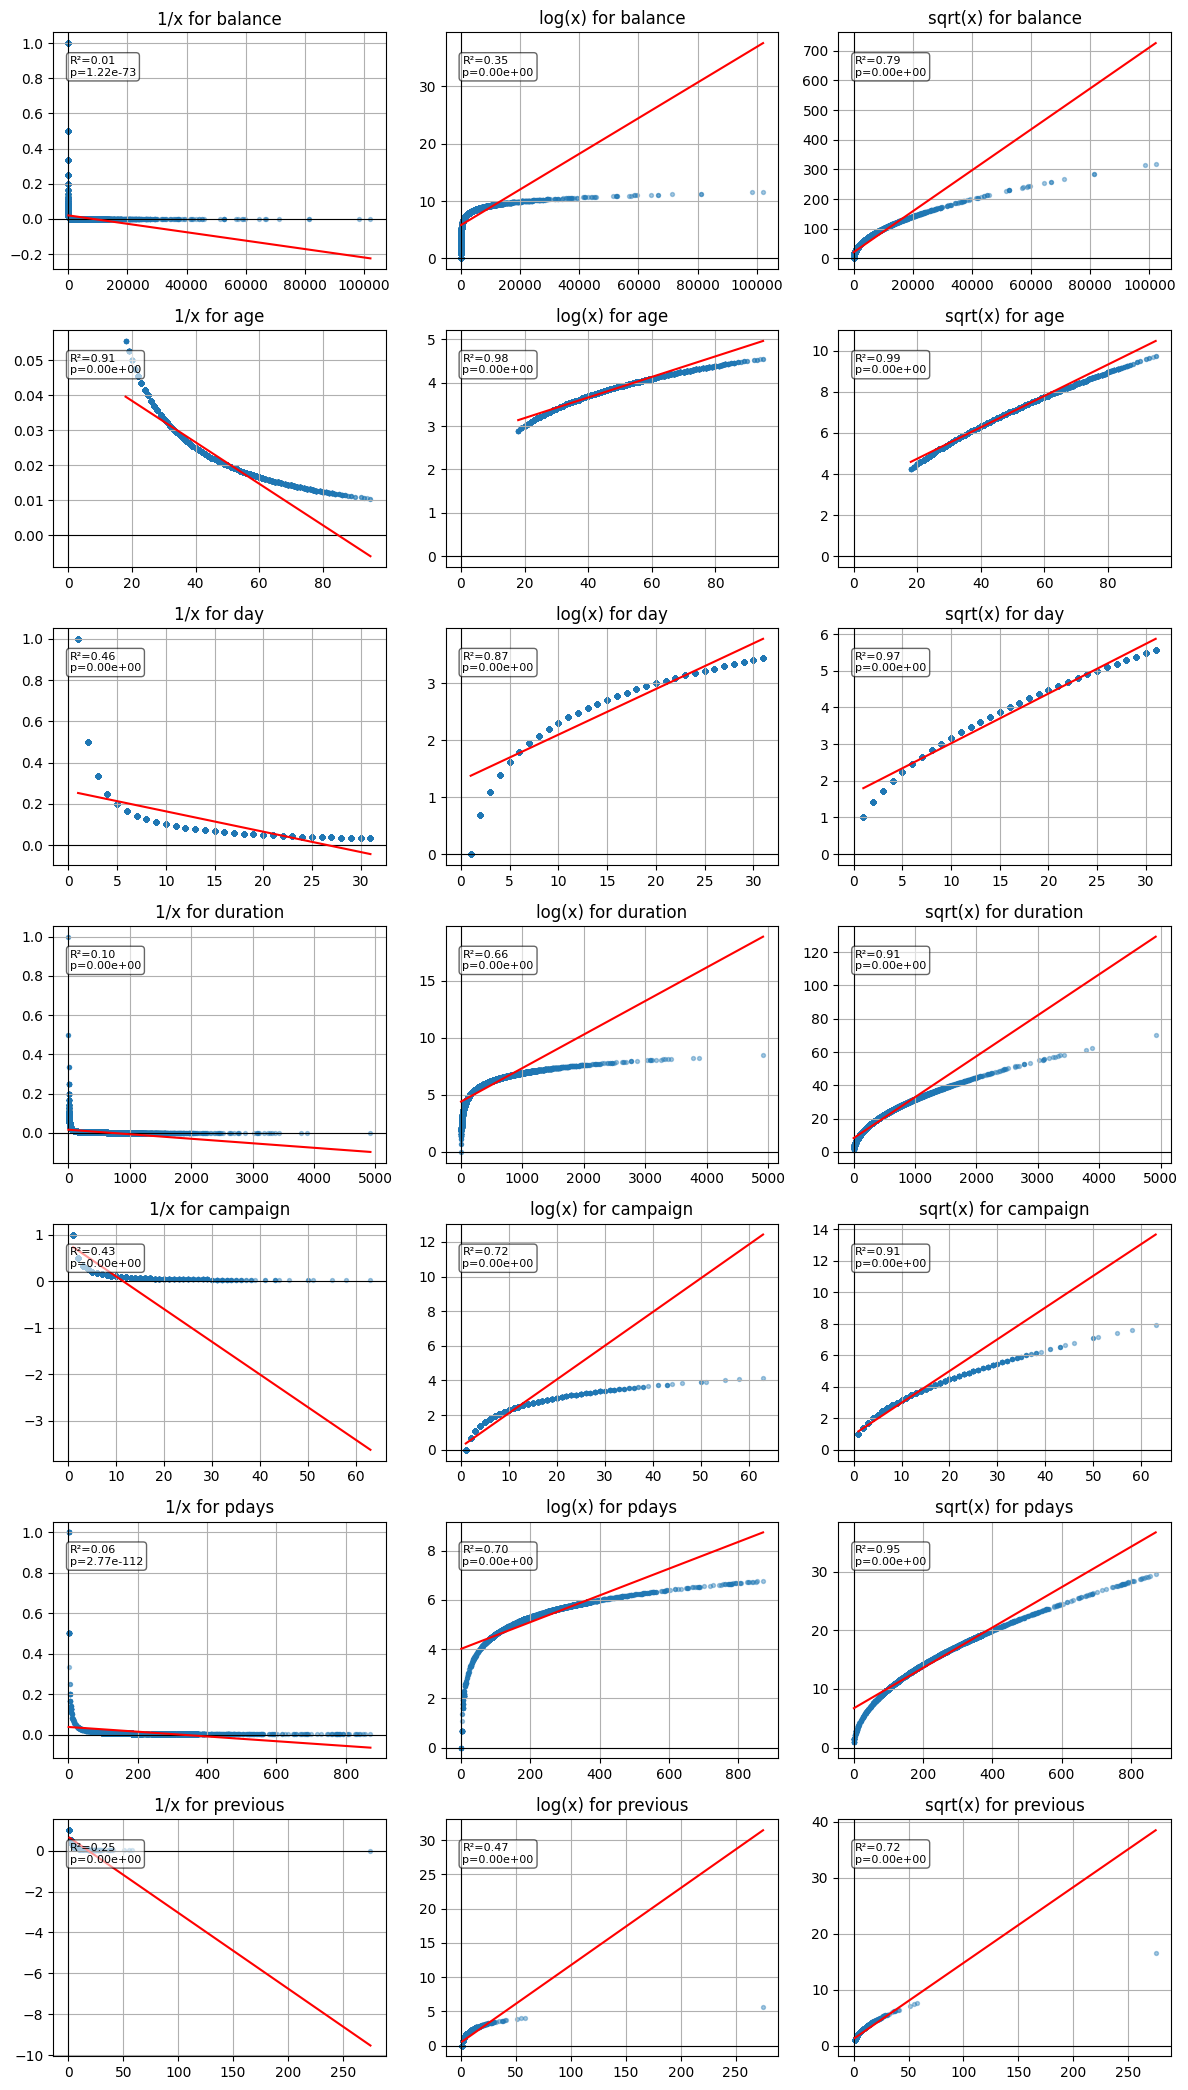

In [19]:
non_linear_assumptions = ["balance", "age", "day", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(7, 3, figsize=(12, 7*3), squeeze=False, sharex=False, sharey=False)

transformations = [
    ("1/x", lambda x: 1 / x),
    ("log(x)", np.log),
    ("sqrt(x)", np.sqrt),
]

for metric, col in enumerate(non_linear_assumptions): #iterate over the columns and the rows of the subplot
    x = bank_total_no_labels[col].astype(float)
    x = x[x > 0]

    for column, (name, f) in enumerate(transformations): #iterate over the transformations and the columns of the subplot
        y = f(x)
        ax = axes[metric, column]

        ax.scatter(x, y, s=8, alpha=0.4)
        ax.axhline(0, color="black", lw=0.8) # add horizontal line at y=0
        ax.axvline(0, color="black", lw=0.8) # add vertical line at x=0 to see if data is of type mx+b where b = 0

        slope, intercept, r, p, _ = stats.linregress(x, y) # eyes are not a good judge of linearity, so we can use a linear regression to see if the data is linear or not. If the p value is less than 0.05, we can reject the null hypothesis that the data is not linear.
        text_str = f"R²={r**2:.2f}\np={p:.2e}" # the R^2 and P val
        ax.text(
                0.05, 0.90, # bottom left corner of the text box in axes coordinates
                text_str, 
                transform=ax.transAxes, # use axes coordinates for positioning the text
                fontsize=8, 
                verticalalignment='top',
                bbox = dict
                    (
                    boxstyle='round',
                    facecolor='white', 
                    alpha=0.6
                    ) 
                )
        
        xx = np.linspace(x.min(), x.max(), 200) # generate 200 points between the minimum and maximum of x to plot the regression line
        ax.plot(xx, intercept + slope * xx, color="red", lw=1.5)

        ax.grid(True)
        ax.set_title(f"{name} for {col}")
        
plt.tight_layout()

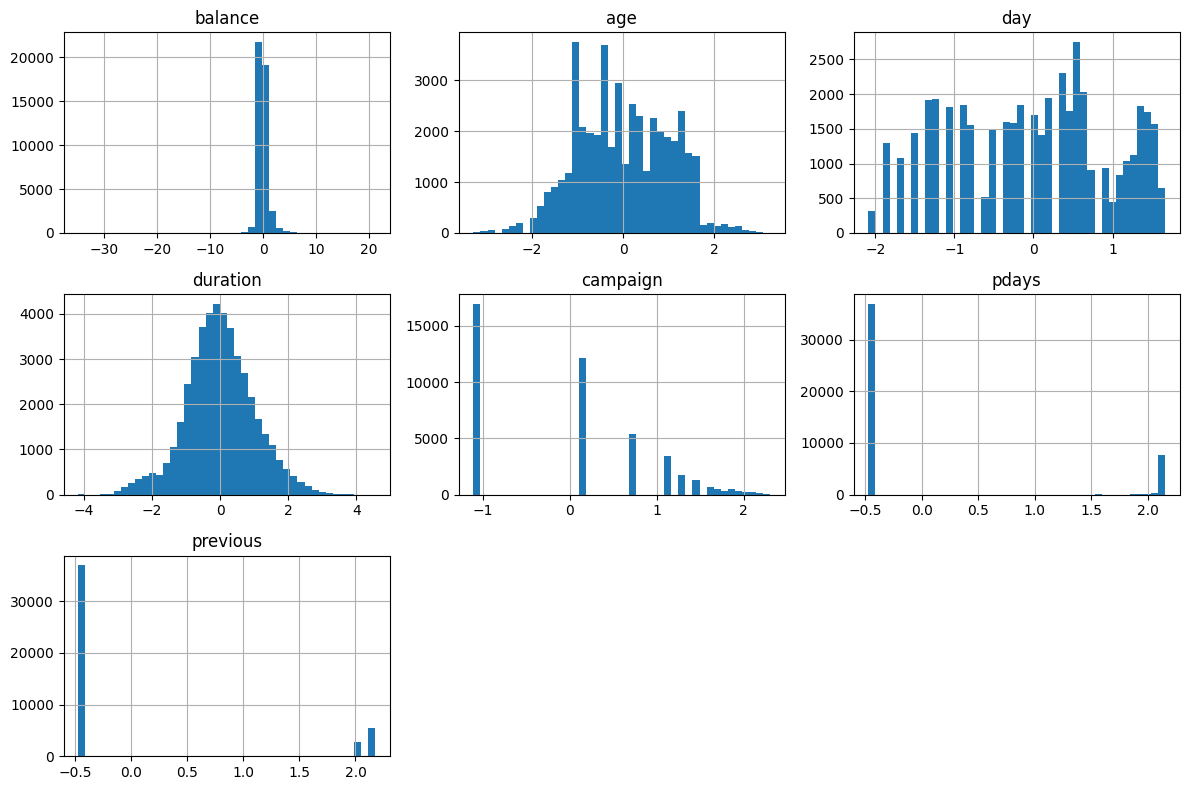

In [ ]:
# although P values are astronomically low, it is i suspect due to the large sample size, which makes even the smallest correlation statistically significant,
# thus i will rely more on the R^2 value to asses the linearity of the transfroemd features.
# and although we cant blindly trust our eyes, it seems that there exist better power law transformation out there for this cases, but to find it by hand
# using grid search like mehtod would be too time consuming, thus i will use a more robust method that can find the best power law transformation for
#  each feature, which is the Yeo-Johnson transformation.
# which i chose over other methods because it is the most robust and "plug-and-play" solution for a general ML pipeline (as per google search ai)
# learn something new every day, i didnt know about this transformation before, and it seems to be the best option for this case, as it can handle zero and negative values, unlike log transformation and guessing.

from sklearn.pipeline import Pipeline

num_transform_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=True))
])

bank_x_train_transformed = bank_x_train.copy()
bank_x_test_transformed = bank_x_test.copy()

bank_x_train_transformed[attributes] = num_transform_pipeline.fit_transform(bank_x_train[attributes])
bank_x_test_transformed[attributes] = num_transform_pipeline.transform(bank_x_test[attributes])

bank_total_transformed = pd.concat([bank_x_train_transformed, bank_x_test_transformed], ignore_index=True)

bank_total_transformed[attributes].hist(bins=42, figsize=(12, 8))
plt.tight_layout()

In [ ]:
# 1. Access the lambdas found by Yeo-Johnson
print("Optimized Lambda values per feature:")
for col, lmbda in zip(attributes, pt.lambdas_):
    print(f"{col}: {lmbda:.4f}")

# 2. Visualize Original vs Transformed
fig, axes = plt.subplots(len(attributes), 2, figsize=(10, 20))

yeo_step = num_transform_pipeline.named_steps['yeo_johnson']

for i, col in enumerate(attributes):
    # Raw distribution
    axes[i, 0].hist(bank_total_no_labels[col], bins=50, color='skyblue', alpha=0.7)
    axes[i, 0].set_title(f"Original: {col}")
    
    # Transformed distribution
    axes[i, 1].hist(bank_total_transformed[col], bins=50, color='salmon', alpha=0.7)
    axes[i, 1].set_title(f"Transformed: {col} (λ={yeo_step.lambdas_[i]:.3f})")

plt.tight_layout()
plt.show()

### Attribute Combinations

In [163]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [164]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

The new bedrooms_per_room attribute is much more correlated with the median house value than the total number of rooms or bedrooms.

## Prepare the Data for ML Algorithms

### Get the Labels

Let's revert to the original training set and separate the target (note that `strat_train_set.drop()` creates a copy of `strat_train_set` without the column, it doesn't actually modify `strat_train_set` itself, unless you pass `inplace=True`):

In [165]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

### Data Cleaning

We have many option to deal with missing data:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

The best practice would be to create a copy of `housing` for each option and work on that copy to avoid breaking `housing`. Perform your analysis with each option and later choose the one that gave up better performance.

In [166]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


**Option 1**: get rid of rows

In [167]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


**Option 2**: get rid of the whole attribute

In [168]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


**Option 3**: replace missing values with some heuristics

In [169]:
housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


We should compute the median value on the training set, and use it to fill the missing values in the training set, but also save the median value as we will need it later to replace missing values in the **test set**!

Scikit-Learn provides a handy class to take care of missing values: **SimpleImputer**. 

Here is how to use it. First, we need to create a SimpleImputer instance, specifying that we want to replace each attribute’s missing values with the median of that attribute:

In [170]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):

In [171]:
housing_num = housing.select_dtypes(include=[np.number])

Now we can fit the imputer instance to the training data using the fit() method:

In [172]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

The imputer has simply computed the median of each attribute and stored the result in its statistics_ instance variable (only the total_bedrooms attribute had missing values)

In [173]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

Check that this is the same as manually computing the median of each attribute:

In [174]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

Now we can use this “trained” imputer to transform the training set by replacing missing values by the learned medians:

In [175]:
X = imputer.transform(housing_num)

In [176]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

The result is a plain NumPy array containing the transformed features. If we want to put it back into a Pandas DataFrame:

In [177]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [178]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [179]:
imputer.strategy

'median'

## Handling Text and Categorical Attributes

Now let's preprocess the categorical input feature, `ocean_proximity`:

In [180]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


We can use Scikit-Learn’s **Ordinal Encoder** class:

In [181]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [182]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [183]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In this case, a one-hot encoding would be more appropriate. 

Scikit-Learn provides a **OneHotEncoder** class to convert categorical values into one-hot vectors

In [184]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [185]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [186]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Alternatively, we can set `sparse_output=False` when creating the `OneHotEncoder` 

In [187]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [188]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### Feature Scaling

With few exceptions, Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales.

There are two common ways to get all attributes to have the same scale: 
- **min-max scaling** ("normalization"): values are shifted and rescaled so that they end up ranging from 0 to 1. (subtract the min value and divide by the max minus the min) 

- **standardization**: subtract the mean value and then divide by the standard deviation (so that the resulting distribution has zero mean and unit variance)

In [189]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [190]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

## Transformation Pipelines

As we saw, there are many data transformation steps that need to be executed in the right order. 

Scikit-Learn provides the **Pipeline** class to help with such sequences of transformations. Here is a small pipeline for the numerical attributes:

The Pipeline constructor takes a list of name/estimator pairs defining a sequence of steps. 

More on pipelines later...

In [191]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In [192]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [193]:
num_pipeline.steps

[('impute', SimpleImputer(strategy='median')),
 ('standardize', StandardScaler())]

In [194]:
num_pipeline[1]

StandardScaler()

In [195]:
num_pipeline[:-1]

Pipeline(steps=[('impute', SimpleImputer(strategy='median'))])

So far, we have handled the categorical columns and the numerical columns separately. 

It would be more convenient to have a single transformer able to handle all columns, applying the appropriate transformations to each column.

We will use the **ColumnTransformer** class.

We get the list of numerical column names and the list of categorical column names and we construct a ColumnTransformer. 

The constructor requires a list of tuples, where each tuple contains a name, a transformer and a list of names (or indices) of columns that the transformer should be applied to. 

In [196]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("1hot", OneHotEncoder(handle_unknown="ignore"))])

# full preprocessing pipeline
# apply the numeric pipeline to the numeric attributes
# apply the categorical pipeline to the categorical attributes
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

Finally, we apply this ColumnTransformer to the housing data: it applies each transformer to the appropriate columns and concatenates the outputs along the second axis (the transformers must return the same number of rows).

In [197]:
housing_prepared = preprocessing.fit_transform(housing)

In [198]:
preprocessing.get_feature_names_out()

array(['num__longitude', 'num__latitude', 'num__housing_median_age',
       'num__total_rooms', 'num__total_bedrooms', 'num__population',
       'num__households', 'num__median_income',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN'], dtype=object)

In [199]:
# We can get a DataFrame out if we want
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(2)

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


In [200]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 13)

In [201]:
preprocessing.get_feature_names_out()

array(['num__longitude', 'num__latitude', 'num__housing_median_age',
       'num__total_rooms', 'num__total_bedrooms', 'num__population',
       'num__households', 'num__median_income',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN'], dtype=object)

# Select and Train a Model

### Training and Evaluating on the Training Set

Let’s first train a Linear Regression model

In [202]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
# make_pipeline is a convenience function that creates a pipeline
# and automatically names the steps based on the classes used
# it is equivalent to the following code:
# lin_reg = Pipeline([
#     ("preprocessing", preprocessing),
#     ("linear_regression", LinearRegression()),
# ])
# but it is shorter and more convenient

# here we create a pipeline that first applies the preprocessing
# and then fits a linear regression model
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('1hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('linearregression', LinearRegression())])

Let's try the full preprocessing pipeline on a few training instances:

In [203]:
# now we can use the pipeline to make predictions!
# we just use the prediction method of the pipeline
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([270900., 334800., 119900., 109200., 305600.])

Compare against the actual values:

In [204]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

It works, although the predictions are not exactly accurate...

In [205]:
# computes the error ratios for the first 5 predictions
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-40.9%, -30.8%, 17.9%, 13.6%, -15.5%


In [206]:
from sklearn.metrics import mean_squared_error

def root_mean_squared_error(labels, predictions):
    return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68232.83515124217

Not a great score: most districts’ median_housing_values range between $120,000 and $265,000, so a typical prediction error of $68,628 is not very satisfying...

This is an example of a **model underfitting** the training data. When this happens it can mean that the features do not provide enough information to make good predictions, or that the model is not powerful enough

Let’s try a more complex model to see how it does...

In [207]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('1hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [208]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

Very suspicious! Likely, the model has badly overfit the data.
How can we be sure? 

If we don't want to use the test set yet, we can split our train set and use a part of it for "**validation**".

### Using Cross-Validation

We will use Scikit-Learn’s **K-fold cross-validation** feature. 

The following code randomly splits the training set into 10 distinct subsets called folds, then it trains and evaluates the Decision Tree model 10 times, picking a different fold for evaluation every time and training on the other 9 folds. The result is an array containing the 10 evaluation scores.

In [209]:
from sklearn.model_selection import cross_val_score

# cross-validation features expect a utility function (greater is better) 
# rather than a cost function (lower is better), 
# so the scoring function is actually the opposite of the MSE
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [210]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     68778.541172
std       1606.882060
min      66941.100114
25%      67347.392808
50%      68653.791710
75%      69967.922873
max      71446.436634
dtype: float64

In [211]:
# compute the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     68306.123074
std       1033.877134
min      67256.179029
25%      67382.038666
50%      68034.978143
75%      68994.956490
max      69930.026817
dtype: float64

Let's try an even more powerful model

**Warning:** the following cell may take a few minutes to run:

In [212]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [213]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     48920.517843
std        715.207292
min      47479.120613
25%      48492.372660
50%      49001.090516
75%      49386.763452
max      49998.347019
dtype: float64

Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [214]:
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

18057.976055305204

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

## Model Fine-Tuning

### Grid Search

Now let's finetune the most promising model.

Instead of trying hyperparameter tuning by hand, we will let Scikit-Learn’s **GridSearchCV** search for us. 

All we need to do is tell it which hyperparameters we want it to experiment with, and what values to try out, and it will evaluate all the possible combinations of hyperparameter values, using cross-validation.

In [215]:
from sklearn.model_selection import GridSearchCV

# here we create a grid of hyperparameters to search over
# we will use a grid search to find the best hyperparameters
# and use cross-validation to evaluate the models

# n_estimators: number of trees in the forest
# max_features: number of features to consider when looking for the best split
# bootstrap: whether to use bootstrap samples or not

param_grid = [
        # 2 x 3 combinations
        {'n_estimators': [3, 10], 'max_features': [2, 4, 6]}, 
        # 2 x 3 combinations with no bootstrap
        {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                            scoring='neg_mean_squared_error',
                            return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6], 'n_estimators': [3, 10]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

The best hyperparameter combination found:

In [216]:
# this will give us the best hyperparameters
grid_search.best_params_

{'bootstrap': False, 'max_features': 4, 'n_estimators': 10}

In [217]:
# this will give us the best estimator
grid_search.best_estimator_

RandomForestRegressor(bootstrap=False, max_features=4, n_estimators=10)

Let's look at the score of each hyperparameter combination tested during the grid search:

In [218]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# we filter the columns to show only the relevant ones
cv_res = cv_res[["params", "mean_test_score", "std_test_score",
                 "mean_train_score", "std_train_score"]]
cv_res.head()

,params,mean_test_score,std_test_score,mean_train_score,std_train_score
11,"{'bootstrap': False, 'max_features': 4, 'n_est...",-2.663884e+09,6.188774e+07,-3.857684e+00,7.350054e+00
5,"{'max_features': 6, 'n_estimators': 10}",-2.715955e+09,5.114983e+07,-4.924202e+08,1.237610e+07
9,"{'bootstrap': False, 'max_features': 3, 'n_est...",-2.754322e+09,9.203618e+07,-2.394764e+02,4.717035e+02
3,"{'max_features': 4, 'n_estimators': 10}",-2.757725e+09,2.339307e+07,-5.118462e+08,3.631535e+06
7,"{'bootstrap': False, 'max_features': 2, 'n_est...",-2.840072e+09,5.795901e+07,-2.700081e+03,4.812954e+03


## Randomized Search

The grid search approach is fine when we are exploring relatively few combinations, like in the previous example, but when the hyperparameter search space is large, it is often preferable to use **RandomizedSearchCV** instead.

This class can be used in much the same way as the GridSearchCV class, but instead of trying out all possible combinations, it evaluates a given number of random combinations by selecting a random value (from a target distribution) for each hyperparameter at every iteration

In [219]:
# more on this later on in the course!

## Evaluate Our Model on the Test Set

In [220]:
final_model = grid_search.best_estimator_

In [221]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test = preprocessing.fit_transform(X_test)

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

55581.10117258591
